In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Veriyi Yükleme
df = pd.read_csv('train_users_2.csv')

In [3]:
#İlk 5 Satırı Görüntüleme
df.head()

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
0,gxn3p5htnn,2010-06-28,20090319043255,NaN,-unknown-,NaN,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,NDF
1,820tgsjxq7,2011-05-25,20090523174809,NaN,MALE,38.0,facebook,0,en,seo,google,untracked,Web,Mac Desktop,Chrome,NDF
2,4ft3gnwmtx,2010-09-28,20090609231247,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,2011-12-05,20091031060129,2012-09-08,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,2010-09-14,20091208061105,2010-02-18,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US


In [4]:
#Veri türlerini ve sütunları inceleme
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213451 entries, 0 to 213450
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       213451 non-null  object 
 1   date_account_created     213451 non-null  object 
 2   timestamp_first_active   213451 non-null  int64  
 3   date_first_booking       88908 non-null   object 
 4   gender                   213451 non-null  object 
 5   age                      125461 non-null  float64
 6   signup_method            213451 non-null  object 
 7   signup_flow              213451 non-null  int64  
 8   language                 213451 non-null  object 
 9   affiliate_channel        213451 non-null  object 
 10  affiliate_provider       213451 non-null  object 
 11  first_affiliate_tracked  207386 non-null  object 
 12  signup_app               213451 non-null  object 
 13  first_device_type        213451 non-null  object 
 14  firs

In [5]:
#Bazı İstatistiksel Çıktılar
df.describe()

,timestamp_first_active,age,signup_flow
count,2.134510e+05,125461.000000,213451.000000
mean,2.013085e+13,49.668335,3.267387
std,9.253717e+09,155.666612,7.637707
min,2.009032e+13,1.000000,0.000000
25%,2.012123e+13,28.000000,0.000000
50%,2.013091e+13,34.000000,0.000000
75%,2.014031e+13,43.000000,0.000000
max,2.014063e+13,2014.000000,25.000000


In [6]:
#Eksik Veri Kontrolü
df.isnull().sum()

id                              0
date_account_created            0
timestamp_first_active          0
date_first_booking         124543
gender                          0
age                         87990
signup_method                   0
signup_flow                     0
language                        0
affiliate_channel               0
affiliate_provider              0
first_affiliate_tracked      6065
signup_app                      0
first_device_type               0
first_browser                   0
country_destination             0
dtype: int64

In [7]:
# 2. Veri Ön İşleme (Data Preprocessing)
# Modeli yanıltabilecek gereksiz/tarihsel sütunları çıkarıyoruz
df = df.drop(['id', 'date_account_created', 'timestamp_first_active', 'date_first_booking'], axis=1)

In [8]:
# Eksik verileri (Missing Values) doldurma
df['age'].fillna(df['age'].median(), inplace=True)
df['first_affiliate_tracked'].fillna(df['first_affiliate_tracked'].mode()[0], inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213451 entries, 0 to 213450
Data columns (total 12 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   gender                   213451 non-null  object 
 1   age                      213451 non-null  float64
 2   signup_method            213451 non-null  object 
 3   signup_flow              213451 non-null  int64  
 4   language                 213451 non-null  object 
 5   affiliate_channel        213451 non-null  object 
 6   affiliate_provider       213451 non-null  object 
 7   first_affiliate_tracked  213451 non-null  object 
 8   signup_app               213451 non-null  object 
 9   first_device_type        213451 non-null  object 
 10  first_browser            213451 non-null  object 
 11  country_destination      213451 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 19.5+ MB


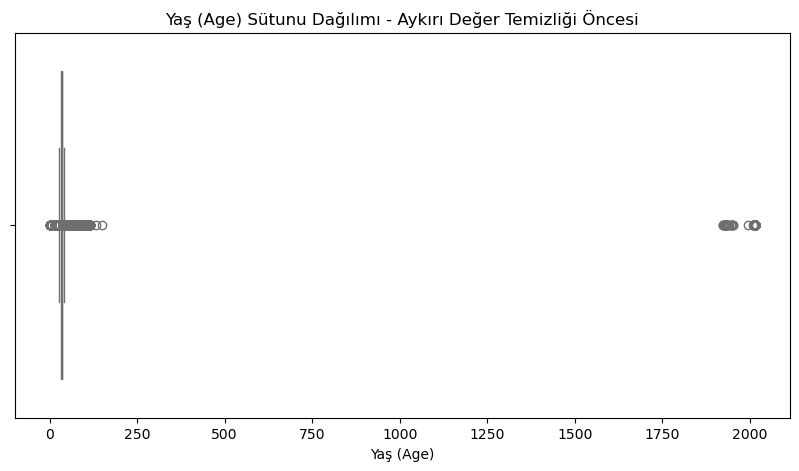

In [10]:
# Boxplot (Kutu Grafiği) çizimi - Aykırı değerleri (Outliers) görme
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['age'], color='skyblue')
plt.title('Yaş (Age) Sütunu Dağılımı - Aykırı Değer Temizliği Öncesi')
plt.xlabel('Yaş (Age)')
plt.show()

In [11]:
# GRAFİKTEN SONRAKİ TEMİZLİK VE ÖN İŞLEME ADIMLARI
# Yaş sütunundaki mantıksız aykırı değerleri sınırlandırma (Grafikte görülen hataları düzeltme)
df.loc[df['age'] > 100, 'age'] = df['age'].median()
df.loc[df['age'] < 18, 'age'] = 18

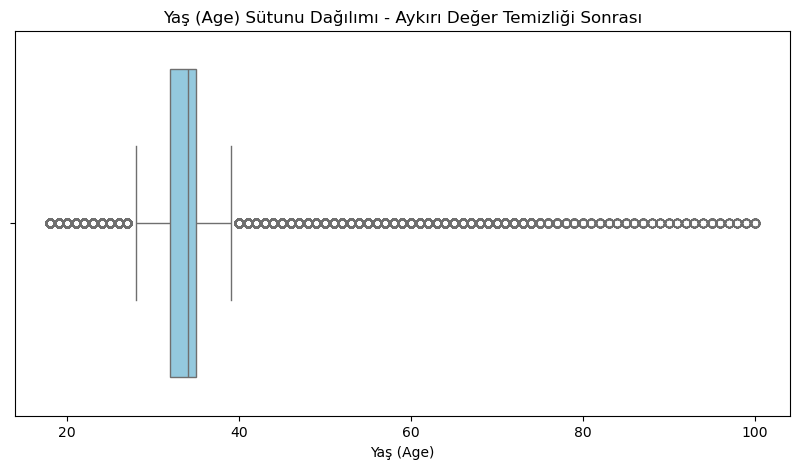

In [12]:
#Aykırı Değer Optimizasyonu Sonrası
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['age'], color='skyblue')
plt.title('Yaş (Age) Sütunu Dağılımı - Aykırı Değer Temizliği Sonrası')
plt.xlabel('Yaş (Age)')
plt.show()

In [13]:
# Kategorik değişkenleri sayısala çevirme (Label Encoding)
label_encoder = LabelEncoder()
kategorik_sutunlar = df.select_dtypes(include=['object']).columns

for sutun in kategorik_sutunlar:
    df[sutun] = label_encoder.fit_transform(df[sutun])

In [14]:
# Hedef değişken (y) ve bağımsız değişkenleri (X) ayırma
X = df.drop('country_destination', axis=1)
y = df['country_destination']

In [15]:
# Algoritmaların daha iyi çalışması için veriyi ölçeklendirme (Standartlaştırma)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [16]:
# Tüm modeller aynı veri üzerinde eğitilmelidir kuralı
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
print("\nVeri ön işleme tamamlandı!")
print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)


Veri ön işleme tamamlandı!
Eğitim seti boyutu: (170760, 11)
Test seti boyutu: (42691, 11)


In [18]:
# 1. Modelleri tanımlama
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}
# 2. Sonuçları tutacağımız kelime
results = {}

In [19]:
print("Modeller eğitiliyor, bu işlem veri setinin büyüklüğüne göre birkaç dakika sürebilir...\n")

Modeller eğitiliyor, bu işlem veri setinin büyüklüğüne göre birkaç dakika sürebilir...



In [20]:
# 3. Modelleri sırayla eğiten döngü
for model_name, model in models.items():
    print(f"-> İşlem yapılıyor: {model_name}...")
    
    # Modeli eğitme
    model.fit(X_train, y_train)
    
    # Tahmin yapma
    y_pred = model.predict(X_test)

    # Metrikleri hesaplama
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Sonuçları ana sözlüğe kaydetme
    results[model_name] = [acc, prec, rec, f1]    

-> İşlem yapılıyor: Logistic Regression...
-> İşlem yapılıyor: Random Forest...
-> İşlem yapılıyor: Gradient Boosting...


In [21]:
# Değerlendirme metriklerini hesaplama (Çok sınıflı olduğu için average='weighted' kullanıyoruz) 
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

In [22]:
# Sonuçları kaydetme
results[model_name] = [acc, prec, rec, f1]

In [23]:
# Sonuçları tablo (DataFrame) haline getirme
results_df = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1-score']).T

In [24]:
print("\n--- Default Modellerin Karşılaştırma Tablosu ---")
display(results_df)


--- Default Modellerin Karşılaştırma Tablosu ---


,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.590148,0.482662,0.590148,0.500170
Random Forest,0.599236,0.530187,0.599236,0.558392
Gradient Boosting,0.628095,0.537608,0.628095,0.575890


In [25]:
# 1. Modeller için denenecek parametre sözlükleri
param_grids = {
    "Logistic Regression": {
        'C': [0.1, 1.0, 10.0],
        'max_iter': [500, 1000]
    },
    "Random Forest": {
        'n_estimators': [50, 100, 200],      # Ağaç sayısı
        'max_depth': [None, 10, 20],         # Ağaçların derinliği
        'min_samples_split': [2, 5, 10]      # Bölünme için gereken minimum örnek
    },
    "Gradient Boosting": {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.1, 0.2],   # Öğrenme hızı
        'max_depth': [3, 5]
    }
}

optimized_results = {}
best_models = {} # En iyi modelleri sonradan kullanmak istersek diye kaydediyoruz

print("Hiperparametre optimizasyonu başlıyor...\n(Bilgisayarınızın hızına göre 10-20 dakika sürebilir, lütfen hücrenin bitmesini bekleyin)\n")

for model_name, model in models.items():
    print(f"-> Optimize ediliyor: {model_name}...")

    # RandomizedSearchCV kurulumu
    # n_iter=5: Her model için 5 farklı rastgele parametre kombinasyonu dener
    # cv=3: 3 Katlı Çapraz Doğrulama (Cross-Validation) yapar
    random_search = RandomizedSearchCV(
        estimator=model, 
        param_distributions=param_grids[model_name], 
        n_iter=50, 
        cv=3, 
        scoring='accuracy', 
        random_state=42,
        n_jobs=-1 
    )

    # Optimizasyonu başlat
    random_search.fit(X_train, y_train)


    # Bulunan en iyi modeli ve parametreleri kaydet
    best_model = random_search.best_estimator_
    best_models[model_name] = best_model
    
    print(f"   En iyi parametreler: {random_search.best_params_}")

    # Test seti üzerinde EN İYİ modelle tahmin yapma
    y_pred_opt = best_model.predict(X_test)
    
    # Metrikleri hesaplama
    acc = accuracy_score(y_test, y_pred_opt)
    prec = precision_score(y_test, y_pred_opt, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred_opt, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred_opt, average='weighted', zero_division=0)
    
    optimized_results[model_name] = [acc, prec, rec, f1]

Hiperparametre optimizasyonu başlıyor...
(Bilgisayarınızın hızına göre 10-20 dakika sürebilir, lütfen hücrenin bitmesini bekleyin)

-> Optimize ediliyor: Logistic Regression...
   En iyi parametreler: {'max_iter': 500, 'C': 0.1}
-> Optimize ediliyor: Random Forest...
   En iyi parametreler: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 10}
-> Optimize ediliyor: Gradient Boosting...
   En iyi parametreler: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}


In [26]:
# Sonuçları Tablo Haline Getirme
opt_results_df = pd.DataFrame(optimized_results, index=['Accuracy', 'Precision', 'Recall', 'F1-score']).T

print("\n--- Optimize Edilmiş Modellerin Karşılaştırma Tablosu ---")
display(opt_results_df)


--- Optimize Edilmiş Modellerin Karşılaştırma Tablosu ---


,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.590171,0.482683,0.590171,0.500165
Random Forest,0.628282,0.536317,0.628282,0.574105
Gradient Boosting,0.629126,0.539545,0.629126,0.577799


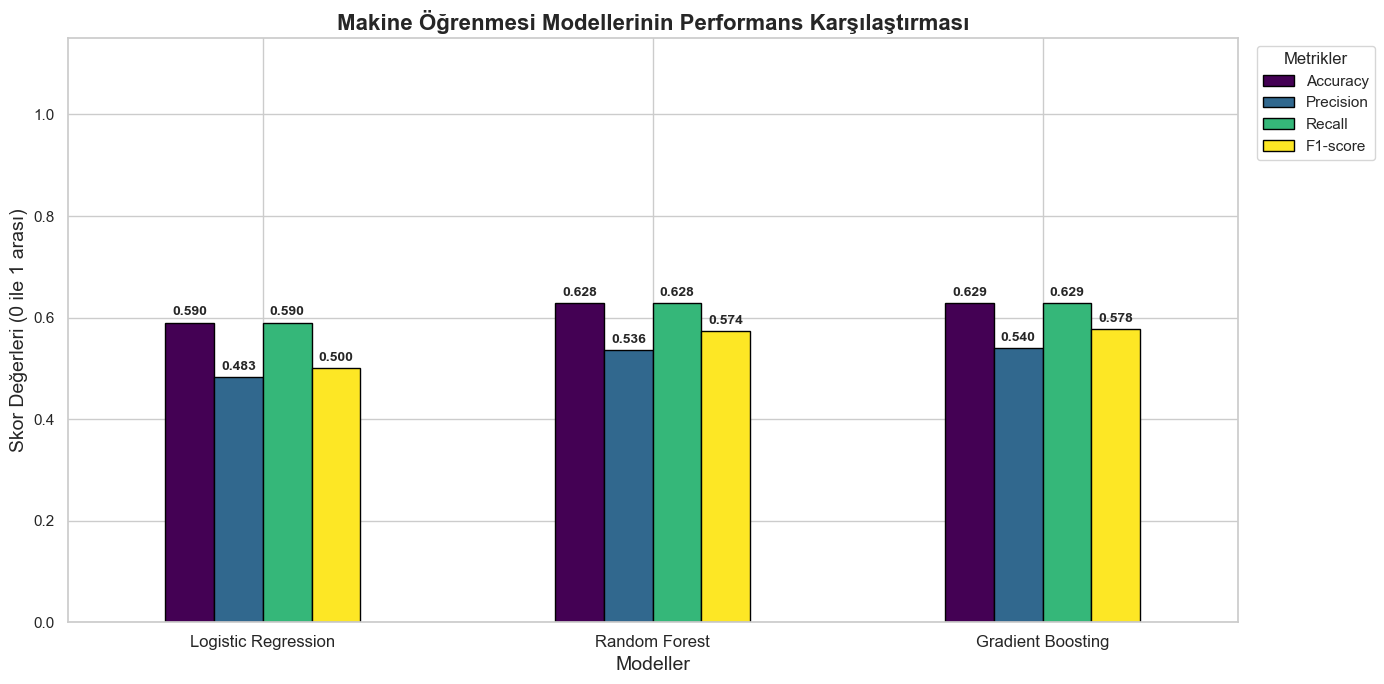

In [27]:
# Grafiğin stilini ayarlama
sns.set_theme(style="whitegrid")

# Çubuk grafik (Bar Chart) oluşturma
# opt_results_df tablosundaki verileri kullanıyoruz.
# (Eğer default modeller için çizeceksen opt_results_df yerine results_df yazabilirsin)
ax = opt_results_df.plot(kind='bar', figsize=(14, 7), colormap='viridis', edgecolor='black')

# Grafik başlığı ve eksen isimlendirmeleri
plt.title('Makine Öğrenmesi Modellerinin Performans Karşılaştırması', fontsize=16, fontweight='bold')
plt.xlabel('Modeller', fontsize=14)
plt.ylabel('Skor Değerleri (0 ile 1 arası)', fontsize=14)

# X eksenindeki yazıları düzeltme
plt.xticks(rotation=0, fontsize=12)

# --- YENİ EKLENEN KISIM: Değerleri barların üzerine yazdırma ---
for container in ax.containers:
    # fmt='%.3f' ile virgülden sonra 3 basamak gösterilmesini sağlıyoruz
    # padding=3 ile rakamların barın çizgisine çok yapışmasını engelliyoruz
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10, fontweight='bold')

# Lejantı (Metrik isimlerini) grafiğin dışına taşıma
plt.legend(title='Metrikler', bbox_to_anchor=(1.01, 1), loc='upper left')

# Y eksenini 0 ile 1.15 arasında sabitleme (Etiketlerin en üstte kesilmemesi için biraz pay bıraktık)
plt.ylim(0, 1.15)

# Grafiğin ekrana tam oturmasını sağlama
plt.tight_layout()

# Grafiği gösterme
plt.show()

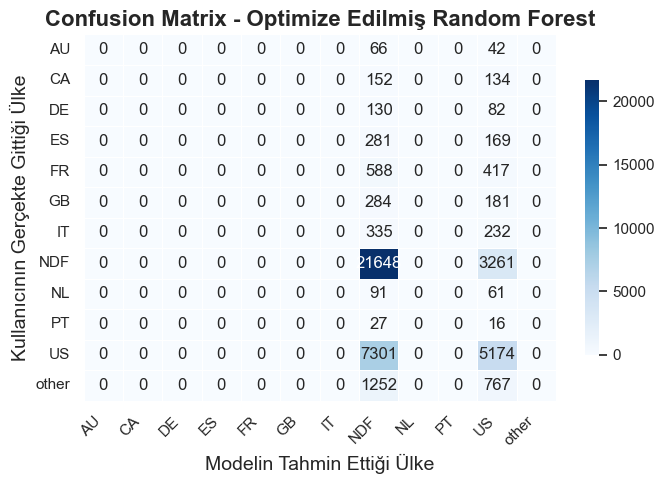

In [28]:
# Confusion Matrix (Karmaşıklık Matrisi) Görselleştirmesi 1
en_iyi_rf_modeli = best_models["Random Forest"]
y_pred_matrix = en_iyi_rf_modeli.predict(X_test)
cm = confusion_matrix(y_test, y_pred_matrix)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Confusion Matrix - Optimize Edilmiş Random Forest', fontsize=16, fontweight='bold')
plt.xlabel('Modelin Tahmin Ettiği Ülke', fontsize=14)
plt.ylabel('Kullanıcının Gerçekte Gittiği Ülke', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

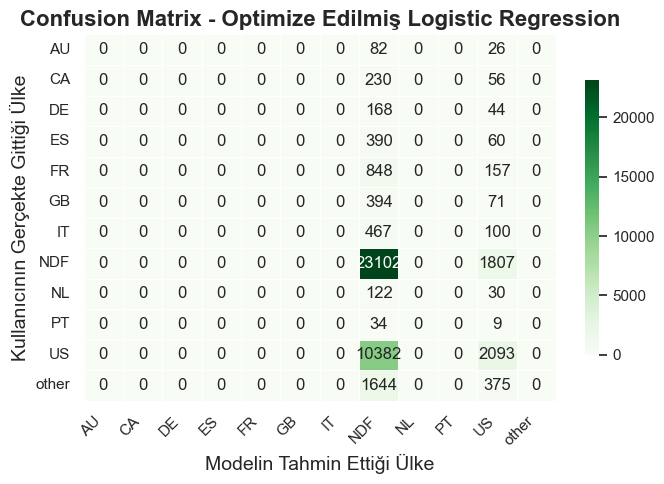

In [31]:
# Confusion Matrix (Karmaşıklık Matrisi) Görselleştirmesi 2
en_iyi_rf_modeli = best_models["Logistic Regression"]
y_pred_matrix = en_iyi_rf_modeli.predict(X_test)
cm = confusion_matrix(y_test, y_pred_matrix)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Confusion Matrix - Optimize Edilmiş Logistic Regression', fontsize=16, fontweight='bold')
plt.xlabel('Modelin Tahmin Ettiği Ülke', fontsize=14)
plt.ylabel('Kullanıcının Gerçekte Gittiği Ülke', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

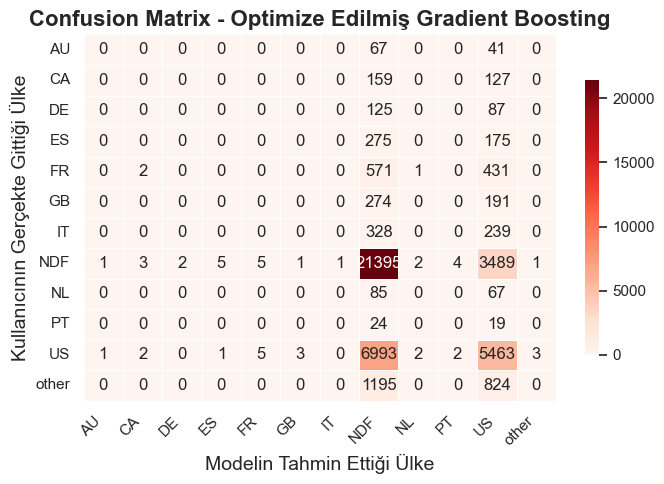

In [32]:
# Confusion Matrix (Karmaşıklık Matrisi) Görselleştirmesi 3
en_iyi_rf_modeli = best_models["Gradient Boosting"]
y_pred_matrix = en_iyi_rf_modeli.predict(X_test)
cm = confusion_matrix(y_test, y_pred_matrix)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Confusion Matrix - Optimize Edilmiş Gradient Boosting', fontsize=16, fontweight='bold')
plt.xlabel('Modelin Tahmin Ettiği Ülke', fontsize=14)
plt.ylabel('Kullanıcının Gerçekte Gittiği Ülke', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()